In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 (실행하면 버전과 폰트가 출력됩니다)
# ─────────────────────────────────────────────
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다. 머신러닝에서는 random_state로도 고정합니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

print("환경 준비 완료! 라이브러리 버전을 확인합니다.")
import sklearn
print(f"- numpy       {np.__version__}")
print(f"- pandas      {pd.__version__}")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- 그래프 한글 폰트: {plt.rcParams['font.family'][0]}")

환경 준비 완료! 라이브러리 버전을 확인합니다.
- numpy       2.4.6
- pandas      3.0.3
- scikit-learn 1.9.0
- 그래프 한글 폰트: Malgun Gothic


In [2]:
# ─────────────────────────────────────────────
# [C2] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터
# 모두플레이 구독자 데이터 생성 — 실행하면 앞 5행과 두 타겟의 요약이 출력됩니다
# (생성 규칙은 지금 이해하지 않아도 됩니다. 이후 모든 Part가 이 데이터를 씁니다)
# ─────────────────────────────────────────────
def make_moduplay(n=2000, seed=RANDOM_STATE):
    """모두플레이 구독자 데이터를 만듭니다. 피처=지난달 행동, 타겟=다음 달 결과."""
    rng = np.random.default_rng(seed)

    # 겉으로 드러나지 않는 '서비스에 붙어 있는 정도'(0~1) — 모든 행동의 뿌리입니다
    engagement = rng.beta(2.2, 2.2, n)

    tenure = rng.integers(1, 49, n)                                     # 가입 기간(개월)
    watch_h = np.clip(rng.normal(5 + 40 * engagement, 5.5, n), 0.3, None)   # 지난달 총 시청(시간)
    avg_daily = np.clip(watch_h * 60 / 30 + rng.normal(0, 2.0, n), 0.5, None)  # 일평균 시청(분)
    avg_session = np.clip(rng.normal(18 + 75 * engagement, 11, n), 4, None)    # 평균 세션 길이(분)
    days_since = np.clip(rng.poisson(0.8 + 17 * (1 - engagement) ** 1.5, n), 0, 30)  # 마지막 시청 후 경과일
    titles = rng.poisson(1.5 + 24 * engagement, n)                      # 시작한 작품 수
    completion = np.clip(rng.normal(0.22 + 0.55 * engagement, 0.11, n), 0.02, 1.0)   # 완주율
    tickets = rng.poisson(0.25 + 1.3 * (1 - engagement), n)             # 문의 건수
    devices = 1 + rng.binomial(3, 0.15 + 0.55 * engagement, n)          # 사용 기기 수
    fee = rng.choice([9900, 14900, 19900], n, p=[0.45, 0.35, 0.20])     # 월 요금(원)

    df = pd.DataFrame({
        "tenure_months": tenure,
        "watch_hours_last_month": watch_h.round(1),
        "avg_daily_watch_min": avg_daily.round(1),
        "avg_session_min": avg_session.round(1),
        "days_since_last_watch": days_since,
        "titles_started": titles,
        "completion_rate": completion.round(3),
        "support_tickets": tickets,
        "device_count": devices,
        "monthly_fee": fee,
    })

    # 타겟 ①(회귀) 다음 달 시청 시간 — 지난달 습관이 이어지고, 오래 안 본 사람은 떨어집니다
    watch_next = (0.58 * df["watch_hours_last_month"]
                  + 0.055 * df["avg_session_min"]
                  + 6.0 * df["completion_rate"]
                  - 0.32 * df["days_since_last_watch"]
                  + 0.35 * df["device_count"]
                  + 0.02 * df["tenure_months"]
                  + 3.0
                  + rng.normal(0, 7.2, n))            # 세상의 우연 = 잡음
    df["watch_hours_next_month"] = np.clip(watch_next, 0, None).round(1)

    # 타겟 ②(분류) 다음 달 이탈 여부 — 확률을 만든 뒤 동전을 던집니다
    z = (1.15
         + 0.175 * df["days_since_last_watch"]
         - 0.070 * df["watch_hours_last_month"]
         - 2.10 * df["completion_rate"]
         + 0.38 * df["support_tickets"]
         - 0.028 * df["tenure_months"]
         - 0.20 * df["device_count"]
         + rng.normal(0, 0.55, n))
    df["churn"] = (rng.random(n) < 1 / (1 + np.exp(-z))).astype(int)
    return df


# 예측에 쓸 피처 10개 (타겟 2개는 제외 — 서로가 서로의 정답이 되면 안 됩니다)
FEATURES = ["tenure_months", "watch_hours_last_month", "avg_daily_watch_min",
            "avg_session_min", "days_since_last_watch", "titles_started",
            "completion_rate", "support_tickets", "device_count", "monthly_fee"]

moduplay = make_moduplay()

print(f"모두플레이 구독자 데이터: {moduplay.shape[0]:,}명 × {moduplay.shape[1]}열")
print(f"  피처 {len(FEATURES)}개 + 타겟 2개")
print(f"  다음 달 평균 시청 시간: {moduplay['watch_hours_next_month'].mean():.1f}시간")
print(f"  다음 달 이탈 비율     : {moduplay['churn'].mean():.3f}")
print()
print(moduplay.head().to_string())

모두플레이 구독자 데이터: 2,000명 × 12열
  피처 10개 + 타겟 2개
  다음 달 평균 시청 시간: 22.8시간
  다음 달 이탈 비율     : 0.325

   tenure_months  watch_hours_last_month  avg_daily_watch_min  avg_session_min  days_since_last_watch  titles_started  completion_rate  support_tickets  device_count  monthly_fee  watch_hours_next_month  churn
0             26                    19.0                 40.3             50.8                     11              12            0.359                0             2         9900                     8.0      1
1             11                    28.3                 58.8             48.4                      7              13            0.520                0             2         9900                    25.7      0
2             30                    31.2                 62.5             71.5                      4              14            0.510                2             3        14900                    32.2      0
3             45                    37.4                 73.0    

In [3]:
# [C3] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 한 데이터, 두 개의 질문
# 같은 2,000명에게서 뽑은 두 타겟의 생김새 비교
y_reg = moduplay["watch_hours_next_month"]   # 회귀용 타겟: 다음 달 시청 시간
y_clf = moduplay["churn"]                    # 분류용 타겟: 다음 달 이탈 여부

print("[회귀] 다음 달 시청 시간 — \"얼마나?\"")
print(f"  타겟 y 예시: {y_reg.head(5).tolist()}")
print(f"  값의 범위  : {y_reg.min():.1f} ~ {y_reg.max():.1f} 시간")
print(f"  서로 다른 값: {y_reg.nunique()}가지  ← 연속 숫자")
print()
print("[분류] 다음 달 이탈 여부 — \"어느 쪽?\"")
print(f"  타겟 y 예시: {y_clf.head(5).tolist()}")
print(f"  값의 종류  : {sorted(y_clf.unique().tolist())}  (0=유지, 1=이탈)")
print(f"  서로 다른 값: {y_clf.nunique()}가지  ← 정해진 범주")
print(f"  이탈 비율  : {y_clf.mean():.3f}")

[회귀] 다음 달 시청 시간 — "얼마나?"
  타겟 y 예시: [8.0, 25.7, 32.2, 30.3, 16.0]
  값의 범위  : 0.0 ~ 63.3 시간
  서로 다른 값: 448가지  ← 연속 숫자

[분류] 다음 달 이탈 여부 — "어느 쪽?"
  타겟 y 예시: [1, 0, 0, 0, 0]
  값의 종류  : [0, 1]  (0=유지, 1=이탈)
  서로 다른 값: 2가지  ← 정해진 범주
  이탈 비율  : 0.325


In [ ]:
# [C4] ◀ Part 1 · ⌨️ 백문이 불여일타! (1)
# ⌨️ 백문이 불여일타! (1) — 비즈니스 질문 4개, 회귀일까 분류일까

# 1) "이 신규 회원이 첫 결제까지 며칠 걸릴까?" 회귀
# 2) "이 이메일은 스팸일까?" 분류
# 3) "이번 달 매장 매출액은 얼마일까?" 회귀 
# 4) "이 거래는 사기일까?" 분류


# 여기에 코드를 작성하세요 — 각 질문의 판정(회귀/분류)과 근거를 주석으로 정리해보세요
# 1번은 첫 결제까지 일수를 찾고 3번은 매출액을 찾는 것으로 연속형 변수에 해당하므로 회귀, 2, 4의 경우 데이터의 종류나 타입을 카테고리로 지정하기 때문에 분류로 정했습니다.

In [9]:
# [C5] ◀ Part 2 · 🔍 자세히 알아보기 — `train_test_split`으로 데이터를 둘로 나눕니다
from sklearn.model_selection import train_test_split

# 이탈 예측(분류)용 데이터를 학습용/테스트용으로 분리
X = moduplay[FEATURES]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf,
    test_size=0.2,        # 20%를 테스트용으로
    random_state=RANDOM_STATE,
    stratify=y_clf,       # 클래스 비율 유지 (분류에서 중요!)
)

print(f"전체 데이터: {len(X):,}명")
print(f"  학습용(train): {len(X_train):,}명  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  테스트용(test): {len(X_test):,}명  ({len(X_test)/len(X)*100:.0f}%)")
print()
print("이탈 비율 비교 (stratify 덕분에 거의 같습니다)")
print(f"  전체   이탈 비율: {y_clf.mean():.3f}")
print(f"  학습   이탈 비율: {y_train.mean():.3f}")
print(f"  테스트 이탈 비율: {y_test.mean():.3f}")

전체 데이터: 2,000명
  학습용(train): 1,600명  (80%)
  테스트용(test): 400명  (20%)

이탈 비율 비교 (stratify 덕분에 거의 같습니다)
  전체   이탈 비율: 0.325
  학습   이탈 비율: 0.324
  테스트 이탈 비율: 0.325


In [10]:
# [C6] ◀ Part 2 · ⌨️ 백문이 불여일타! (2)
# ⌨️ 백문이 불여일타! (2) — test_size 0.3으로 바꿔 분할 크기 확인

# 여기에 코드를 작성하세요
# [C5] ◀ Part 2 · 🔍 자세히 알아보기 — `train_test_split`으로 데이터를 둘로 나눕니다
from sklearn.model_selection import train_test_split

# 이탈 예측(분류)용 데이터를 학습용/테스트용으로 분리
X = moduplay[FEATURES]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf,
    test_size=0.3,        # 20%를 테스트용으로
    random_state=RANDOM_STATE,
    stratify=y_clf,       # 클래스 비율 유지 (분류에서 중요!)
)

print(f"전체 데이터: {len(X):,}명")
print(f"  학습용(train): {len(X_train):,}명  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  테스트용(test): {len(X_test):,}명  ({len(X_test)/len(X)*100:.0f}%)")
print()
print("이탈 비율 비교 (stratify 덕분에 거의 같습니다)")
print(f"  전체   이탈 비율: {y_clf.mean():.3f}")
print(f"  학습   이탈 비율: {y_train.mean():.3f}")
print(f"  테스트 이탈 비율: {y_test.mean():.3f}")

전체 데이터: 2,000명
  학습용(train): 1,400명  (70%)
  테스트용(test): 600명  (30%)

이탈 비율 비교 (stratify 덕분에 거의 같습니다)
  전체   이탈 비율: 0.325
  학습   이탈 비율: 0.324
  테스트 이탈 비율: 0.325


In [11]:
# [C7] ◀ Part 3 · 🔍 자세히 알아보기 — 무엇을 "가장 잘 맞는다"고 할까 (MSE·R²)
# MSE를 정의대로 직접 계산 → sklearn 결과와 비교
# (고객 4명의 시청 시간을 예측했다고 가정한 작은 예시입니다)
y_true_demo = np.array([12.0, 30.5, 8.0, 45.0])   # 실제 시청 시간
y_pred_demo = np.array([14.0, 28.0, 9.5, 41.0])   # 모델의 예측

errors = y_true_demo - y_pred_demo          # 오차
mse_manual = np.mean(errors ** 2)           # 정의: 오차 제곱의 평균
print("오차:", errors)
print(f"손계산 MSE = mean({errors.tolist()}^2) = {mse_manual:.4f}")

from sklearn.metrics import mean_squared_error
print(f"sklearn MSE = {mean_squared_error(y_true_demo, y_pred_demo):.4f}")
print("→ 두 값이 같습니다. 공식과 라이브러리는 같은 일을 합니다!")

오차: [-2.   2.5 -1.5  4. ]
손계산 MSE = mean([-2.0, 2.5, -1.5, 4.0]^2) = 7.1250
sklearn MSE = 7.1250
→ 두 값이 같습니다. 공식과 라이브러리는 같은 일을 합니다!


In [12]:
# [C8] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 다음 달 시청 시간 예측
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1) 회귀 데이터를 학습/테스트로 분리 (타겟만 y_reg로 바꿉니다)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE)

# 2) 모델 생성 → 학습(fit) → 예측(predict)
lin = LinearRegression()
lin.fit(Xr_train, yr_train)            # 학습용 데이터로만 학습
yr_pred = lin.predict(Xr_test)         # 테스트 데이터로 예측

# 3) 평가: 테스트 데이터에서 MSE와 R²
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f"테스트 MSE = {mse:.1f}   (제곱 단위라 크기 감이 잘 안 옵니다)")
print(f"테스트 R²  = {r2:.3f}")
print(f"→ 이 모델은 다음 달 시청 시간 변동의 약 {r2*100:.0f}%를 설명합니다.")

테스트 MSE = 48.9   (제곱 단위라 크기 감이 잘 안 옵니다)
테스트 R²  = 0.545
→ 이 모델은 다음 달 시청 시간 변동의 약 54%를 설명합니다.


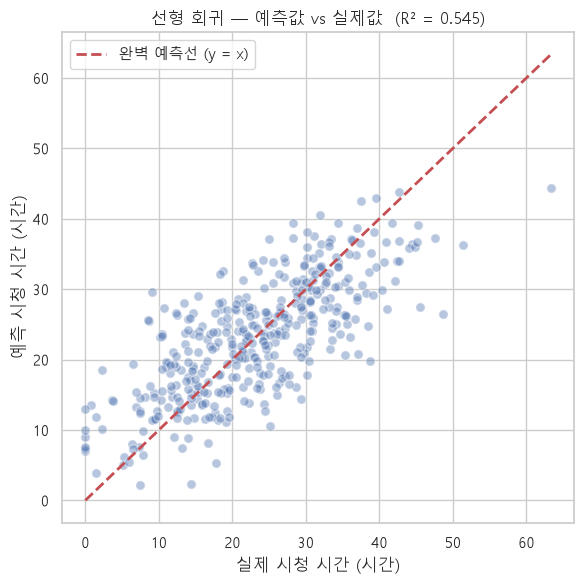

In [13]:
# ─────────────────────────────────────────────
# [C9] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 다음 달 시청 시간 예측
# 예측값 vs 실제값 — 점이 대각선에 가까울수록 잘 맞은 것
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yr_test, yr_pred, alpha=0.4, edgecolor="w", s=45)

# 완벽 예측선 (y = x)
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
ax.plot(lims, lims, "r--", lw=2, label="완벽 예측선 (y = x)")

ax.set_xlabel("실제 시청 시간 (시간)")
ax.set_ylabel("예측 시청 시간 (시간)")
ax.set_title(f"선형 회귀 — 예측값 vs 실제값  (R² = {r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# [C10] ◀ Part 3 · ⌨️ 백문이 불여일타! (3)
# ⌨️ 백문이 불여일타! (3) — 같은 모델, 두 개의 순위

from sklearn.preprocessing import StandardScaler

coef_raw = pd.Series(lin.coef_, index=FEATURES)   # 원래 단위 그대로의 계수
rank_raw = coef_raw.abs().sort_values(ascending=False)
print("=== 원본 피처 기준 순위 ===")
print(rank_raw)

# 2) 표준화 후 다시 학습
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[FEATURES])

lin_scaled = LinearRegression()
lin_scaled.fit(X_scaled, y_reg)

coef_scaled = pd.Series(lin_scaled.coef_, index=FEATURES)
rank_scaled = coef_scaled.abs().sort_values(ascending=False)

print("\n=== 표준화 피처 기준 순위 ===")
print(rank_scaled)

# 3) 두 순위의 1등 비교
print(f"\n원본 기준 1등: {rank_raw.index[0]}")
print(f"표준화 기준 1등: {rank_scaled.index[0]}")
# 여기에 코드를 작성하세요

=== 원본 피처 기준 순위 ===
completion_rate           6.695976
watch_hours_last_month    0.518092
device_count              0.468640
days_since_last_watch     0.266807
avg_session_min           0.059298
support_tickets           0.049437
tenure_months             0.036699
avg_daily_watch_min       0.021594
titles_started            0.004853
monthly_fee               0.000035
dtype: float64

=== 표준화 피처 기준 순위 ===
watch_hours_last_month    3.771671
avg_daily_watch_min       1.837094
days_since_last_watch     1.150884
avg_session_min           1.105076
completion_rate           1.064029
tenure_months             0.432829
device_count              0.412576
titles_started            0.076318
monthly_fee               0.058466
support_tickets           0.040868
dtype: float64

원본 기준 1등: completion_rate
표준화 기준 1등: watch_hours_last_month


In [17]:
# [C11] ◀ Part 3 · 학습한 모델로 "새 고객"을 예측해 봅시다
# 새 입력(테스트셋 첫 고객)에 대한 예측 vs 실제
one = Xr_test.iloc[[0]]              # 처음 보는 고객 1명
pred_one = lin.predict(one)[0]
real_one = yr_test.iloc[0]
print(f"지난달 시청 시간 = {one['watch_hours_last_month'].iloc[0]:.1f}시간")
print(f"예측 시청 시간   = {pred_one:.1f}시간")
print(f"실제 시청 시간   = {real_one:.1f}시간")
print(f"오차(error)      = {real_one - pred_one:+.1f}시간")

지난달 시청 시간 = 14.4시간
예측 시청 시간   = 14.7시간
실제 시청 시간   = 11.8시간
오차(error)      = -2.9시간


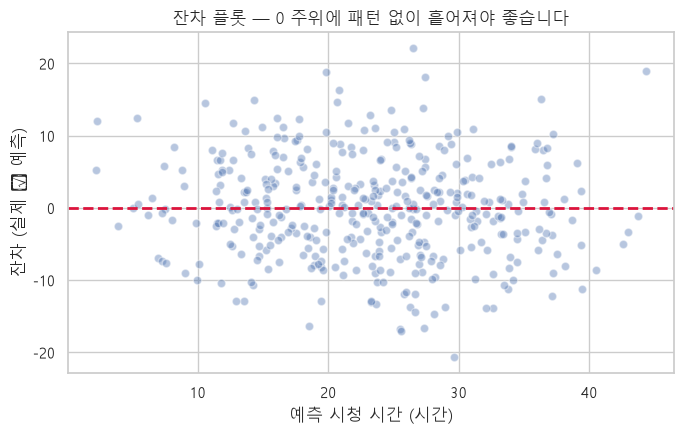

잔차 평균 = -0.10 (0에 가까울수록 편향 없음)
잔차 표준편차 = 6.99


In [18]:
# ─────────────────────────────────────────────
# [C12] ◀ Part 3 · 오차를 들여다보기 — 잔차(Residual)
# 잔차 플롯 — 0 주위에 고르게 흩어질수록 좋다
# ─────────────────────────────────────────────
residuals = yr_test.values - yr_pred
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(yr_pred, residuals, alpha=0.4, edgecolor="w")
ax.axhline(0, color="crimson", ls="--", lw=2)
ax.set_xlabel("예측 시청 시간 (시간)"); ax.set_ylabel("잔차 (실제 − 예측)")
ax.set_title("잔차 플롯 — 0 주위에 패턴 없이 흩어져야 좋습니다")
plt.tight_layout(); plt.show()
print(f"잔차 평균 = {residuals.mean():.2f} (0에 가까울수록 편향 없음)")
print(f"잔차 표준편차 = {residuals.std():.2f}")

In [26]:
# [C13] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 이탈 예측
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 로지스틱 회귀는 피처 크기에 민감 → 스케일 조정 후 학습 (자세한 이유는 피처·Pipeline 시간)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # 학습 데이터로만 기준을 잡고
X_test_s = scaler.transform(X_test)         # 같은 기준으로 테스트 변환 (누수 방지!)

clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)              # 예/아니오 예측
y_proba = clf.predict_proba(X_test_s)[:, 1] # 1(이탈)일 확률

acc = accuracy_score(y_test, y_pred)
print(f"테스트 정확도(Accuracy) = {acc:.3f}")
print()
print("예측 확률 예시 (앞 5명):")
for real, p in zip(y_test[:5], y_proba[:5]):
    decision = "이탈(1)" if p >= 0.5 else "유지(0)"
    print(f"  P(이탈)={p:.3f} → {decision:8s} | 실제={real}")

테스트 정확도(Accuracy) = 0.802

예측 확률 예시 (앞 5명):
  P(이탈)=0.033 → 유지(0)    | 실제=0
  P(이탈)=0.035 → 유지(0)    | 실제=0
  P(이탈)=0.194 → 유지(0)    | 실제=0
  P(이탈)=0.128 → 유지(0)    | 실제=0
  P(이탈)=0.107 → 유지(0)    | 실제=0


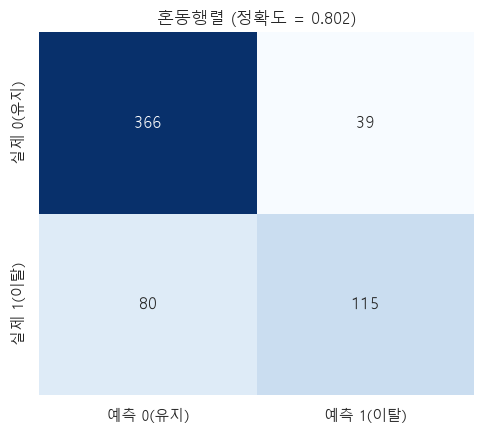

In [24]:
# ─────────────────────────────────────────────
# [C14] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 이탈 예측
# 혼동행렬 — 무엇을 맞히고 무엇을 틀렸나
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title(f"혼동행렬 (정확도 = {acc:.3f})")
plt.tight_layout()
plt.show()

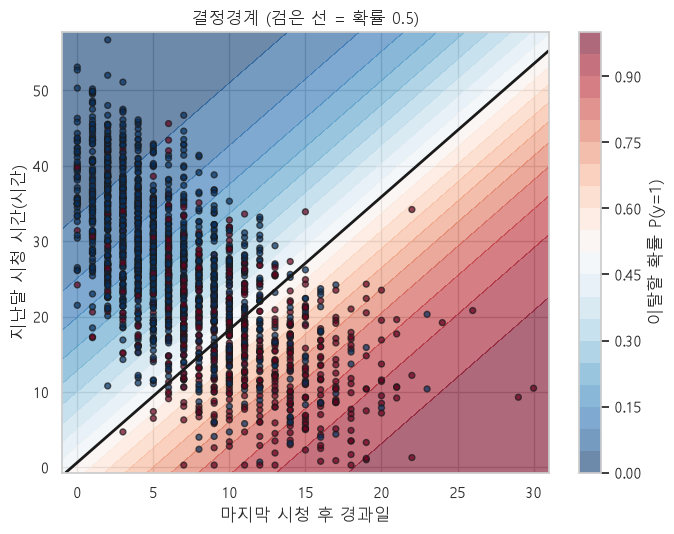

2피처 모델 테스트 정확도 = 0.745


In [28]:
# ─────────────────────────────────────────────
# [C15] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 이탈 예측
# 결정경계 — 로지스틱 회귀가 두 클래스를 가르는 선
# ─────────────────────────────────────────────
# 직관을 위해 피처 2개만 사용
feat = ["days_since_last_watch", "watch_hours_last_month"]
X2 = moduplay[feat].values
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

sc2 = StandardScaler().fit(X2_tr)
clf2 = LogisticRegression(random_state=RANDOM_STATE).fit(sc2.transform(X2_tr), y2_tr)

# 격자 위에서 예측 확률을 계산해 경계를 색칠
xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min()-1, X2[:, 0].max()+1, 200),
    np.linspace(X2[:, 1].min()-1, X2[:, 1].max()+1, 200))
grid = sc2.transform(np.c_[xx.ravel(), yy.ravel()])
zz = clf2.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)  # 결정경계 (P=0.5)
ax.scatter(X2[:, 0], X2[:, 1], c=y_clf, cmap="RdBu_r", edgecolor="k", s=18, alpha=0.7)
plt.colorbar(cf, label="이탈할 확률 P(y=1)")
ax.set_xlabel("마지막 시청 후 경과일"); ax.set_ylabel("지난달 시청 시간(시간)")
ax.set_title("결정경계 (검은 선 = 확률 0.5)")
plt.tight_layout()
plt.show()

print(f"2피처 모델 테스트 정확도 = {clf2.score(sc2.transform(X2_te), y2_te):.3f}")

In [22]:
# [C16] ◀ Part 4 · 로지스틱 회귀의 숨은 선물 — 계수를 "배수"로 해석
# [C15]의 2피처 모델 계수 → 오즈비(exp)로 변환해 방향과 크기 읽기
odds2 = pd.Series(np.exp(clf2.coef_[0]), index=feat)

print("오즈비(Odds Ratio) — 피처가 1 표준편차 커질 때 이탈 오즈가 몇 배가 되나")
for name, v in odds2.items():
    direction = "이탈(1) 쪽" if v > 1 else "유지(0) 쪽"
    print(f"  {name:24s}: x{v:6.3f}  → 값이 클수록 {direction}")
print("\n→ 오래 안 볼수록 이탈 쪽으로, 많이 볼수록 유지 쪽으로 밀립니다.")

오즈비(Odds Ratio) — 피처가 1 표준편차 커질 때 이탈 오즈가 몇 배가 되나
  days_since_last_watch   : x 2.110  → 값이 클수록 이탈(1) 쪽
  watch_hours_last_month  : x 0.398  → 값이 클수록 유지(0) 쪽

→ 오래 안 볼수록 이탈 쪽으로, 많이 볼수록 유지 쪽으로 밀립니다.


In [29]:
# [C18] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 학습 점수 vs 테스트 점수
# 선형 회귀(시청 시간): 학습 R² vs 테스트 R²
r2_train = lin.score(Xr_train, yr_train)
r2_test = lin.score(Xr_test, yr_test)

# 로지스틱 회귀(이탈): 학습 정확도 vs 테스트 정확도
acc_train = clf.score(X_train_s, y_train)
acc_test = clf.score(X_test_s, y_test)

summary = pd.DataFrame({
    "모델": ["선형회귀 (R²)", "로지스틱회귀 (Accuracy)"],
    "학습 점수": [r2_train, acc_train],
    "테스트 점수": [r2_test, acc_test],
})
summary["차이(학습-테스트)"] = summary["학습 점수"] - summary["테스트 점수"]
print(summary.round(3).to_string(index=False))

               모델  학습 점수  테스트 점수  차이(학습-테스트)
        선형회귀 (R²)  0.590   0.545       0.045
로지스틱회귀 (Accuracy)  0.789   0.802      -0.013


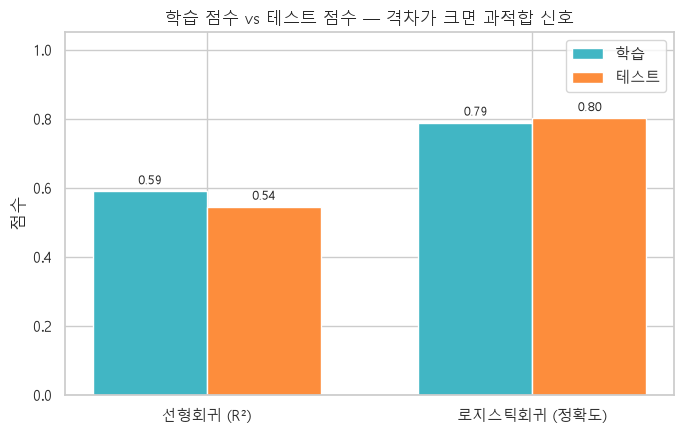

In [30]:
# ─────────────────────────────────────────────
# [C19] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 학습 점수 vs 테스트 점수
# 학습 vs 테스트 점수 — 격차가 크면 과적합 신호
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary["학습 점수"], w, label="학습", color="#41b6c4")
ax.bar(x + w/2, summary["테스트 점수"], w, label="테스트", color="#fd8d3c")
ax.set_xticks(x); ax.set_xticklabels(["선형회귀 (R²)", "로지스틱회귀 (정확도)"])
ax.set_ylabel("점수"); ax.set_ylim(0, 1.05)
ax.set_title("학습 점수 vs 테스트 점수 — 격차가 크면 과적합 신호")
ax.legend()
for i, (tr, te) in enumerate(zip(summary["학습 점수"], summary["테스트 점수"])):
    ax.text(i - w/2, tr + 0.02, f"{tr:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, te + 0.02, f"{te:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [31]:
# ─────────────────────────────────────────────
# [C20] ◀ Part 5 · 베이스라인과 비교 — 우리 모델이 "찍기"보다 나은가?
# 베이스라인(Dummy) — "찍기"와 나란히 세우기
# ─────────────────────────────────────────────
from sklearn.dummy import DummyClassifier, DummyRegressor

# (분류·이탈) 무조건 다수 클래스로 찍는 베이스라인 vs 로지스틱 회귀
dum_clf = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_acc = dum_clf.score(X_test, y_test)   # Dummy는 X 값을 무시하므로 스케일링 불필요
print("[분류·이탈 예측]")
print(f"  베이스라인(무조건 다수) 정확도 = {base_acc:.3f}")
print(f"  로지스틱 회귀 테스트 정확도    = {acc_test:.3f}")
print(f"  → 모델이 베이스라인보다 {acc_test - base_acc:+.3f} 만큼 낫다")

# (회귀·시청 시간) 무조건 평균으로 찍는 베이스라인 vs 선형 회귀 (R² 기준)
dum_reg = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
base_r2 = dum_reg.score(Xr_test, yr_test)
print("\n[회귀·다음 달 시청 시간]")
print(f"  베이스라인(평균 예측) R² = {base_r2:.3f}  (정의상 ~0)")
print(f"  선형회귀 테스트 R²       = {r2_test:.3f}")
print(f"  → 평균 찍기보다 {r2_test - base_r2:+.3f} 만큼 더 설명한다")

[분류·이탈 예측]
  베이스라인(무조건 다수) 정확도 = 0.675
  로지스틱 회귀 테스트 정확도    = 0.802
  → 모델이 베이스라인보다 +0.127 만큼 낫다

[회귀·다음 달 시청 시간]
  베이스라인(평균 예측) R² = -0.001  (정의상 ~0)
  선형회귀 테스트 R²       = 0.545
  → 평균 찍기보다 +0.546 만큼 더 설명한다


In [ ]:
# [C21] ◀ Part 5 · ⌨️ 백문이 불여일타! (5)
# ⌨️ 백문이 불여일타! (5) — 베이스라인 전략 3종 비교, 기준을 어느 것으로 잡을까

strategies = ["most_frequent", "stratified", "uniform"]

# 여기에 코드를 작성하세요

In [ ]:
# [C22] ◀ ❓ 오늘의 퀴즈 · 코드 퀴즈
# 코드 퀴즈 — 빈칸(____)을 채워 로지스틱 회귀 학습·평가
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# (X_train_s, X_test_s, y_train, y_test는 [C13]에서 준비한 그대로입니다)
quiz_model = LogisticRegression(max_iter=5000, random_state=42)
# quiz_model.____(X_train_s, y_train)          # 학습
# pred = quiz_model.____(X_test_s)             # 예측
# print("테스트 정확도:", ____(y_test, pred))   # 평가

# 여기에 코드를 작성하세요